# Agentic Systems - Autonomous Agents

Welcome back, Sacha! You've built a solid foundation across LLM fundamentals, evaluation, and tool use — now it's time to put it all together in something genuinely powerful.

Right now, your LLM applications are still **orc**hestrated by you* — you decide the sequence of steps, which tools to call, when to stop. **Agentic systems** change that: they give your applications the ability to **reason, plan, and act autonomously, deciding their own next steps until a task is complete.

That directly unlocks what you're building toward — a SQL agent that doesn't just answer one question, but can **navigate a financial dataset**, chain tool calls intelligently, and recover when something goes wrong. This course gives you the framework to build exactly that, reliably and at production quality. Let's get started!

With your context set, let's jump into the heart of this course: **AI Agents**.

You've already built LLM applications that call tools — but there's a meaningful leap between an app that calls a tool when told to and one that **decides for itself** what to do next, chains multiple actions together, and knows when it's done. That leap is what separates a chatbot from an agent.

In this lesson, we'll unpack exactly what makes a system agentic, how agents are structured and how they operate — and then build one from scratch using **LangGraph**. Let's dive in!

The term **"AI agent"** has gone from niche jargon to one of the hottest phrases in the industry — and the search trend here tells that story clearly. Interest was relatively flat through early 2024, then accelerated sharply, hitting peak search volume by mid-2025.

This isn't just hype cycles — it reflects a genuine shift in what people are building. The community realized that LLMs paired with tools and autonomy can tackle a much broader class of problems than simple question-answering.

Given your work in financial markets — what comes to mind when you hear **"AI agent"**?

To sharpen it a bit further: we call these systems **AI agents** — software that uses AI to pursue goals and complete tasks on behalf of users. The contrast is with **chatbots**, which primarily answer questions from their knowledge base but don't take actions to accomplish anything in the world.

Think about your SQL agent idea. A chatbot might answer _"what's the best model for predicting mortgage prepayment?"_ from training data. An agent would actually **query your financial database**, pull the relevant features, cross-reference results, and return a grounded answer — acting until the task is complete.

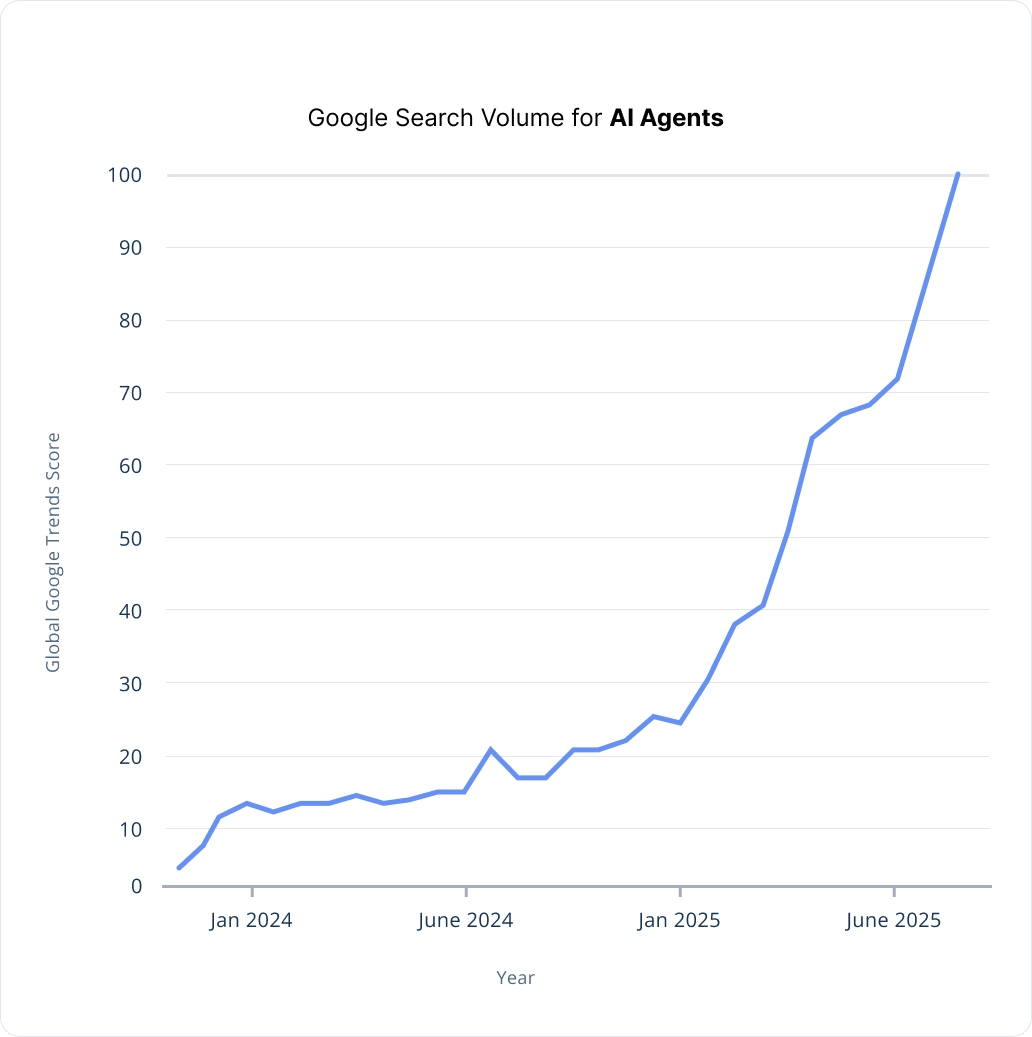

Here's a short demo of **OpenAI's ChatGPT Agent** — under 2 minutes. Watch how it autonomously researches San Francisco budget data across multiple PDFs, extracts hundreds of numbers, and generates a formatted Excel spreadsheet — all from a single prompt.

Pay attention to how it **plans, executes multiple steps, and completes a complex workflow** without being told exactly what to do at each step. That's the agent vs chatbot distinction in action.

Now that you've seen an agent in action, let's build a precise understanding of what makes a system agentic. It helps to think about agents from **three angles**: their **key characteristics**, their **components**, and how they **operate**. Together these give you a complete mental model — and you'll see all three reflected in everything we build. Let's go!

What makes a system agentic? Three defining characteristics:

- **Goal-orientation**: The system is designed to achieve specific objectives — it's task-driven, not just response-driven
- **Autonomy**: It operates independently, making decisions without constant human input
- **Environmental interaction**: It can both perceive its environment (gathering information) and affect it (taking actions)

These aren't abstract — you've already built something that exhibits all three. The Hotel Assistant from the Tool Use course focused on travel-related tasks, independently decided which tools to call, and both gathered information (searching hotels, checking weather) and affected the environment (making bookings).

Would you say your SQL agent idea shares these same characteristics?

Now let's look at what an agent is actually made of. Every agent has four core components:

- **LLM**: The reasoning engine — understands requests and decides what to do next
- **Tools**: Functions that let the agent perceive and act in its environment
- **Memory**: Conversation history and context that inform future decisions
- **Execution Control**: The mechanism that keeps the loop going — or knows when to stop

Your Hotel Assistant from the Tool Use course had all four: an LLM for thinking, tools for searching hotels and making bookings, conversation history as memory, and a while loop that iterated until no more tool calls were needed.

Your SQL agent would follow the same pattern — with tools like list_tables, get_schema, and execute_query in place of the hotel tools.

But before we touch code, one last piece of the conceptual puzzle — **how agents actually operate**. This will make the code click immediately when we get there.

Agents follow a cycle called **ReAct** (Reasoning and Acting):

- Input: Receive the user's task
- Reason: Analyze the situation — what tools are needed?
- Act: Execute those tools
- Observe: Process the results
- Reason again: Are we done, or do we need more actions?
- Repeat until the task is complete

You can see this cycle here — the Reason and Act nodes loop back on each other, with the LLM, Memory, and Tools feeding into that cycle. The loop exits only when the LLM decides the task is done.

This is exactly what your Hotel Assistant was doing with its while loop — just without the formal name. LangGraph will give this pattern a clean, explicit structure.

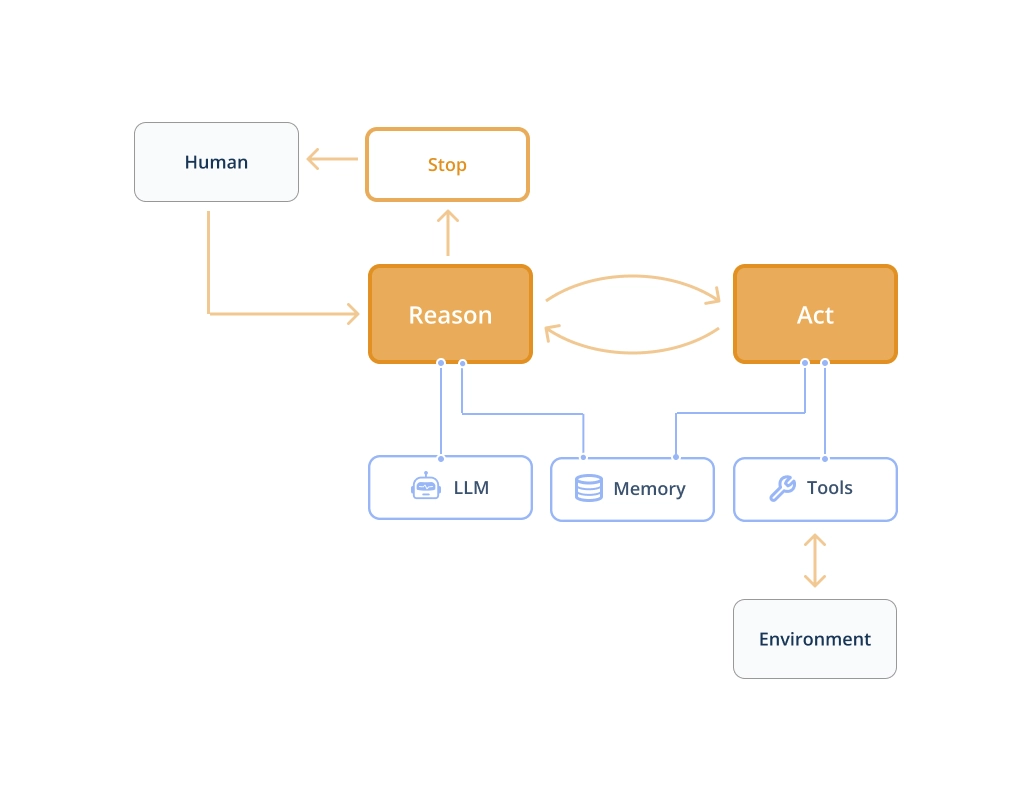

Perfect — now for the framework we'll use to build agentic systems: **LangGraph**.

You've been using **LangChain** throughout this track. For everything we've built so far — chatbots, RAG, tool calling — LangChain is a great fit. But when you move into agentic systems with complex loops, branching logic, and multiple interacting components, LangChain becomes cumbersome.

**LangGraph** was built specifically for this. Created by the same team as LangChain, it gives you:

- A proven framework for structuring agentic systems
- Building blocks to implement virtually any agency-reliability balance
- Cleaner, more maintainable code than rolling your own orchestration logic

Good. Now a natural question: why not just stick with LangChain?

LangChain was built in the **pre-agent era**, optimized for linear workflows — conversation management, RAG, basic tool use. It handles those elegantly, and for your simpler applications it remains the right choice.

But **agentic systems require loops, branching logic, and complex state management** — architectural patterns LangChain wasn't designed for. The code becomes tangled quickly.

**LangGraph** was built specifically to address this. It's worth noting that for chatbots, RAG, and simple tool calling — the kind of work you've done so far — LangGraph would be unnecessary overhead. But for what you're building toward (a SQL agent that chains multiple tools autonomously), it's the right tool.

### LangGraph

In LangGraph, an agentic system is modeled as a directed graph where:

- **Nodes** are the subtasks — Python functions that do actual work (call an LLM, execute tools, process results)
- **Edges** define the flow — which node runs next, and under what conditions

Here you can see our Hotel Assistant's ReAct agent as a LangGraph graph. START feeds into Reason, which either routes to Act (if tools are needed) or straight to END (if the task is done). After Act executes the tools, control flows back to Reason — that's the ReAct loop made explicit.

Notice STATE sitting at the center — that's LangGraph's shared memory, accessible by every node and edge. It's what allows Reason to know what tools were called and what results came back.

This is the same loop your LangChain while True was implementing — just now it has explicit structure you can inspect, extend, and reason about.

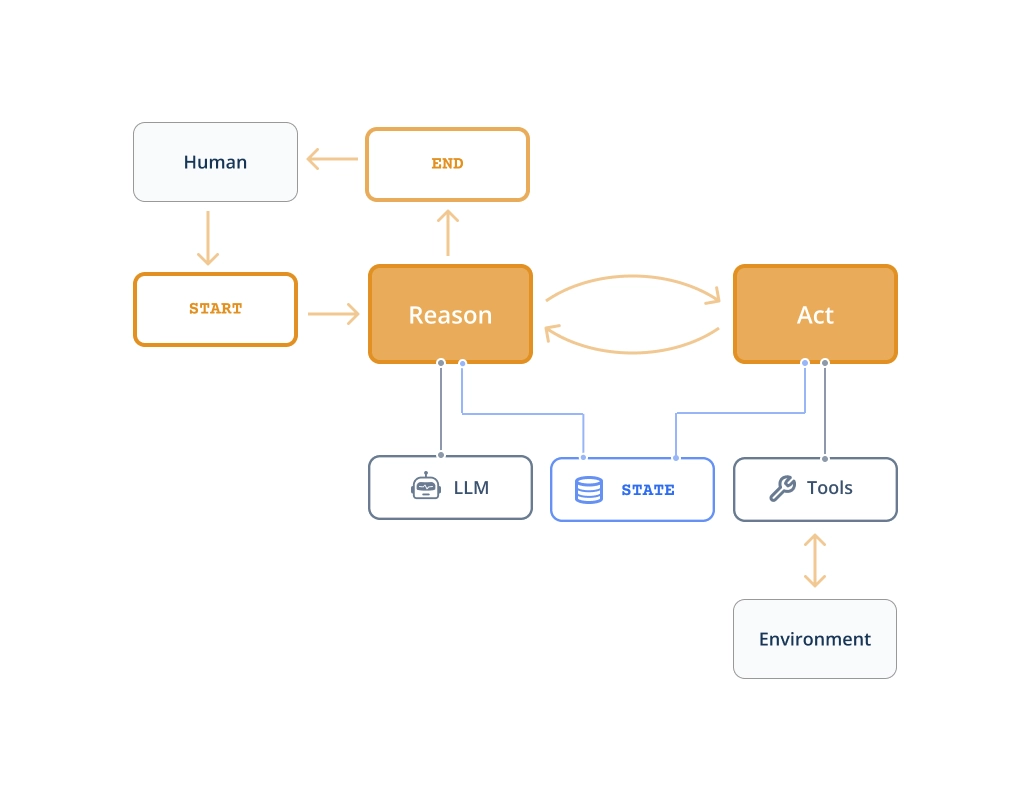


So to put it simply: **nodes do the work, edges tell what to do next**  — and STATE is the shared memory that ties it all together. That mental model will carry you through everything we build.

Alright — time to build! And we're starting with something satisfying: the **Hotel Assistant you already built in LangChain** is our starting point.

That assistant already follows the pure **ReAct pattern** — reason, act, loop until done. Rather than building from scratch, we'll **convert it to LangGraph**, which gives us the perfect entry point: you'll see exactly how the concepts map to code, without the noise of designing a new system from scratch.

This also sets you up directly for the next lesson, where we decompose tasks into more structured agentic workflows. The LangGraph fundamentals you build here are the foundation for everything that follows.

Let's design the system!

Here's how the Hotel Assistant maps to a LangGraph graph — and you can follow along in this figure.

The graph has two nodes and a conditional flow:

- reason **node**: The LLM analyzes the user's request and decides what to do — search hotels, check weather, book a room, or respond directly
- act **node**: Executes whatever tool calls the LLM decided on
- **Edges**: START → reason always; from reason, either → act (if tools needed) or → END (if done); from act → back to reason

This gives the assistant maximum flexibility — it chooses its own sequence of tool calls for any travel request, looping until the task is complete.

In LangGraph terms: nodes do the work, edges define the flow. The reason node doesn't manage the loop — the graph structure handles that automatically. Much cleaner than the while True loop in LangChain.

Now let's talk about **State** — the glue that holds the graph together.

Think of State as the **shared working memory** of your agentic system. Every node reads from it and writes back to it. It's what allows reason to know what tools were called, and what results came back from act.

Looking at the figure, you can see **STATE** sitting at the center — both Reason and Act have access to it. That's intentional: it's the single source of truth for the entire graph at any point in time.

Designing the state schema is typically the first thing you do when modeling an agentic system in LangGraph. The key questions to ask:

- What information does each node need to access?
- What needs to persist between node executions?

For our Hotel Assistant, the answer is straightforward: we need to track the conversation history — the sequence of user messages, LLM responses, and tool results. That's all the nodes need to reason and act correctly.

With that design in mind, let's start building the LangGraph implementation step by step!

Before diving into LangGraph, let's briefly revisit the original LangChain implementation we're converting.

Here's the **tools module** — the same tools you built in the Tool Use course, now isolated into a clean tools.py for better organization. The implementations are abstracted, since the details aren't the focus here.

The six tools available to the assistant:

- `query_hotels`: Searches the hotel database by city and dates
- `calculate_total_cost`: Computes total cost including taxes
- `get_weather`: Retrieves weather for a city and date
- `book_room`: Interfaces with the booking API to reserve rooms
- `web_search`: Provider-managed web search (Claude built-in)
- `MCP time tools`: Time and timezone handling via an MCP server

All of these carry over directly into our LangGraph implementation — nothing changes on the tools side. Any questions?

In [1]:
# Tool implementations
from langchain.tools import tool
import requests
from datetime import date

HOTEL_API_URL = "https://hotel-booking-server-1085074390115.us-east4.run.app"


def search_hotels_db(city: str, check_in: str, check_out: str) -> str:
    """Call the hotel booking API to search for available hotels."""
    response = requests.get(
        f"{HOTEL_API_URL}/hotels/search",
        params={"city": city, "check_in": check_in, "check_out": check_out},
    )
    hotels = response.json()

    if not hotels:
        return "No hotels found matching your criteria."

    formatted = []
    for i, hotel in enumerate(hotels, 1):
        formatted.append(
            f"{i}. {hotel['name']} in {hotel['city']}"
            f" - ${hotel['price_per_night']}/night"
            f" - {hotel['rating']} stars"
        )
    return "\n".join(formatted)


@tool
def query_hotels(city: str, check_in: str, check_out: str) -> str:
    """Search for available hotels in a city for given dates.

    Args:
        city: City name to search hotels in
        check_in: Check-in date (YYYY-MM-DD)
        check_out: Check-out date (YYYY-MM-DD)

    Returns:
        Formatted list of matching hotels with details
    """
    return search_hotels_db(city, check_in, check_out)


@tool
def calculate_total_cost(
    price_per_night: float, num_nights: int, tax_rate: float = 0.05
) -> str:
    """Calculate total hotel cost including taxes."""
    # Calculate subtotal, tax, and total
    # Format and return breakdown
    # ...
    return f"Cost Breakdown:\n- Rate: ${price_per_night} x {num_nights} nights\n- Tax: ${tax}\n- Total: ${total}"


@tool
def get_weather(city: str, date: str = None) -> str:
    """Get weather information for a city."""
    # Implementation:
    # 1. Call geocoding API to get coordinates
    # 2. Call weather API with coordinates
    # 3. Format and return results
    # ...
    return f"Weather in {city}: Sunny, 25°C"


@tool
def book_room(
    hotel_id: int, room_type: str, check_in_date: date, check_out_date: date
) -> str:
    """Book a room in a hotel using the hotel booking API"""
    # Implementation:
    # 1. Check availability
    # 2. Create reservation
    # 3. Return confirmation
    # ...
    return "Room booked successfully! Reservation ID: 12345"


# Configure provider's built-in web search
claude_websearch = {
    "type": "web_search_20250305",
    "name": "web_search",
    "max_uses": 3,
}



And here's the original **LangChain Hotel Assistant** — the HotelAssistant class that orchestrated everything.

The core logic lives in the chat method: a while True loop that calls the LLM, checks for tool calls, executes them, and breaks when there are none left. It also distinguishes between self-managed tools (like query_hotels) and provider/MCP tools handled automatically.

Would you like a quick walkthrough of the code to refresh your memory, or are you comfortable with it and ready to jump into the LangGraph implementation?

In [12]:
prompt = """
You are a comprehensive hotel assistant with access to multiple tools:

1. **query_hotels**: Search for available hotels by city and dates
2. **calculate_total_cost**: Calculate total costs including taxes for
   hotel stays
3. **web_search**: Search the web for current events, venues, and
   attractions (built-in)
4. **get_weather**: Get weather information for any city and date
5. **book_room**: Complete hotel bookings (use hotel_id=1 for testing)
6. **MCP time tools**: Handle timezone conversions, current time queries,
   and date calculations

Tool Use Instructions:

- Use tools thoughtfully—only when they add value to the response
- Chain tools when needed (e.g., search for info, then use that to search
  for relevant hotels)
- Extract hotel IDs from search results when users want to book
- When unsure of the time, use the time tool to get the current time
- Infer context from previous messages (location, dates, preferences)
- Be conversational and helpful
"""

with open("prompt.md",mode='w') as f:
    f.write(prompt)

In [30]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

# Import tools from our tools module
# from tools import query_hotels, calculate_total_cost, get_weather, book_room

load_dotenv()

# Additional imports for LangChain tools
from langchain_community.tools import DuckDuckGoSearchResults


class HotelAssistant:
    def __init__(self):

        # Initialize LLM with MCP support and provider web search
        self.llm = init_chat_model(
            model="gpt-4o-mini",
        )

        # Initialize DuckDuckGo search tool, setting the name to "web_search" is important
        self.web_search = web_search = DuckDuckGoSearchResults(
            name="web_search", output_format="list", num_results=5)


        # Set up self-managed tools
        self.tools = {
            "query_hotels": query_hotels,
            "calculate_total_cost": calculate_total_cost,
            "get_weather": get_weather,
            "book_room": book_room,
            "web_search": self.web_search,  # Provider tool
            # "mcp_toolset": mcp_toolset,  # MCP tool
        }

        # Bind all tools to the LLM
        self.llm_with_tools = self.llm.bind_tools(self.tools.values())
        self.messages = []

        self.system_message = self._get_system_message()

        self.messages.append(self.system_message)

    def _get_system_message(self):
        """
        Load the system prompt from a markdown file.
        """
        with open("prompt.md", "r") as f:
            system_prompt = f.read()

        return SystemMessage(content=system_prompt)

    def chat(self, message: str):
        # Keep track of tool call sequence
        self.current_sequence = []

        # Add user message
        self.messages.append(HumanMessage(content=message))

        # Loop to handle serial tool calls
        while True:
            # Get AI response
            response = self.llm_with_tools.invoke(self.messages)
            self.messages.append(response)

            if not response.tool_calls:
                # No more tools to call
                break

            # Process tool calls
            for tool_call in response.tool_calls:
                self.current_sequence.append(tool_call["name"])

                # Only process self-managed tools
                # Provider and MCP tools are handled automatically
                if tool_call["name"] in [
                    "query_hotels",
                    "calculate_total_cost",
                    "get_weather",
                    "book_room",
                    "web_search",
                ]:
                    tool = self.tools[tool_call["name"]]
                    tool_result = tool.invoke(tool_call)
                    self.messages.append(tool_result)

        # Store sequence for debugging
        self.tool_sequence = self.current_sequence



In [42]:
hotel_agent = HotelAssistant()
query = "can you book an hotel in Tokyo when for the next marathon. Today 4 August 2026. arrive one day before and depart one day after"
result = hotel_agent.chat(query)

In [43]:
for msg in hotel_agent.messages:
    print(msg.pretty_print())

================================ System Message ================================


You are a comprehensive hotel assistant with access to multiple tools:

1. **query_hotels**: Search for available hotels by city and dates
2. **calculate_total_cost**: Calculate total costs including taxes for
   hotel stays
3. **web_search**: Search the web for current events, venues, and
   attractions (built-in)
4. **get_weather**: Get weather information for any city and date
5. **book_room**: Complete hotel bookings (use hotel_id=1 for testing)
6. **MCP time tools**: Handle timezone conversions, current time queries,
   and date calculations

Tool Use Instructions:

- Use tools thoughtfully—only when they add value to the response
- Chain tools when needed (e.g., search for info, then use that to search
  for relevant hotels)
- Extract hotel IDs from search results when users want to book
- When unsure of the time, use the time tool to get the current time
- Infer context from previous messages (loc

Great — now let's build the LangGraph version from scratch, step by step. We'll grow the code incrementally so each piece lands clearly before we add the next.

Here's **Step 1: Setup**. This should look familiar — it's essentially the same initialization as your LangChain version, just reorganized.

Let's start with the **tool definitions**, highlighted in the top section. You can see custom_tools, provider_tools, and mcp_toolset defined separately before being combined into all_tools. When you run this locally with OpenAI, just keep custom_tools and your DuckDuckGo tool — drop the provider and MCP pieces.

In [50]:
from dotenv import load_dotenv

from typing import Annotated

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

load_dotenv()

# SETUP

# Tool definitions (custom, provider, and MCP)
custom_tools = [
    query_hotels,
    calculate_total_cost,
    get_weather,
    book_room,
]
provider_tools = [web_search]

all_tools = custom_tools + provider_tools

# LLM configuration
llm = init_chat_model(
    model="gpt-5-mini",
)
llm_with_tools = llm.bind_tools(all_tools)

# Load system message once at setup time
with open("prompt.md", "r") as f:
    system_prompt = f.read()

system_message = SystemMessage(content=system_prompt)



The new stuff starts now: **State definition**.

Look at the new block at the bottom. The State class is a TypedDict with a single key: messages. That's it — our entire state schema is just the conversation history.

Two things to notice in that one line:

- `list[AnyMessage]`: the state holds a list of LangChain message objects (HumanMessage, AIMessage, ToolMessage...)
- `Annotated[..., add_messages]`: this attaches a reducer to the messages key

`add_messages` is called a reducer — I'll explain exactly what that means and why it matters in the next message. Any questions about the state schema itself?

In [52]:
# STATE DEFINITION

from langgraph.graph.message import AnyMessage, add_messages
from typing_extensions import TypedDict


# Define state schema with messages using add_messages reducer
class State(TypedDict):
    """Define the state schema for our hotel assistant.""" ""

    messages: Annotated[list[AnyMessage], add_messages]


Now let's understand **reducers** — this is where LangGraph's state management gets interesting.

When a node finishes its work, it doesn't modify the state directly. Instead, it returns a partial update — just the changes it wants to make. LangGraph then uses a reducer function to merge that update into the existing state.

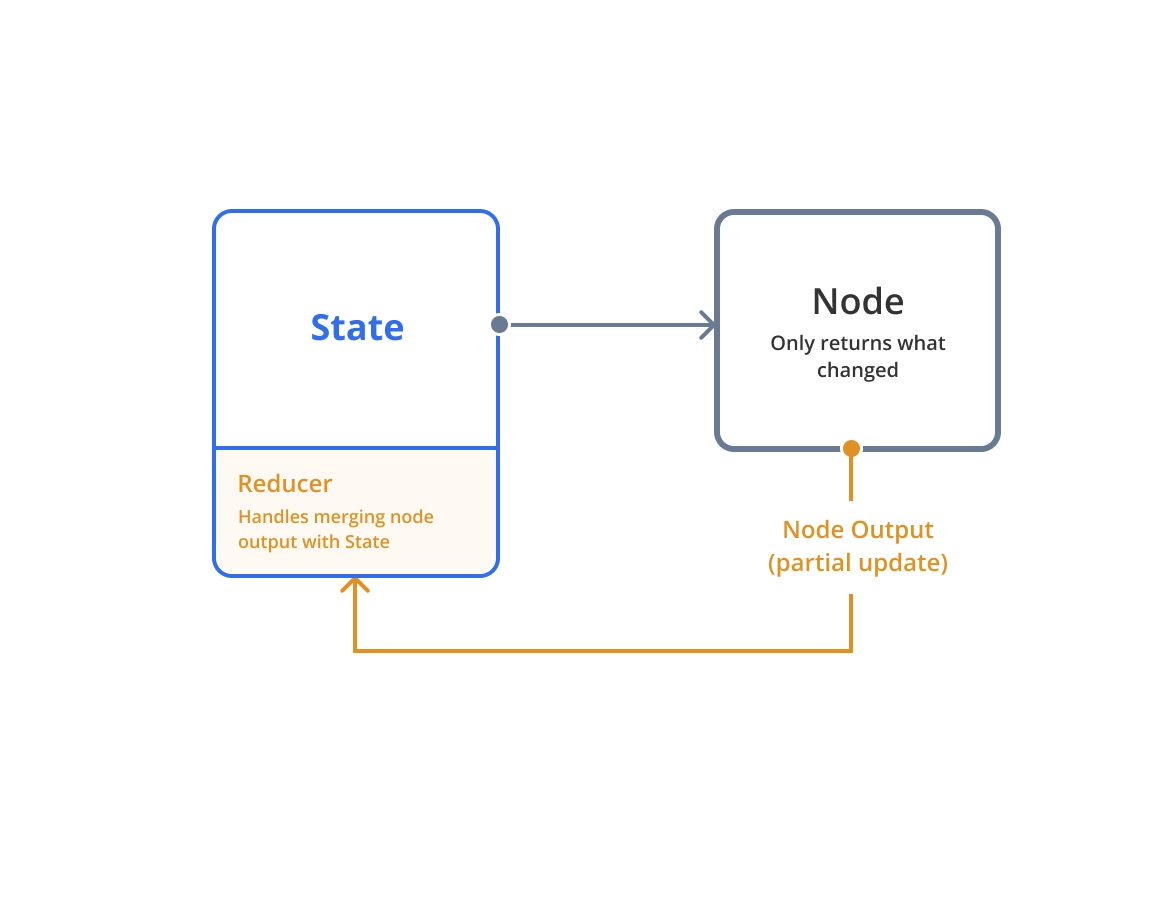

Look at this figure: the node only returns what changed, and the reducer handles combining that with the current state. This clean separation means nodes stay simple and focused — they just do their job and return results.

For each key in your state schema, you can attach a different reducer. If you don't specify one, updates simply replace the existing value. But for messages, replacement would wipe the conversation history every time a node runs — which is exactly what we don't want.

That's why add_messages exists: instead of replacing, it appends new messages to the existing list, preserving the full conversation history.

Beyond add_messages, LangGraph provides a couple of other built-in reducers worth knowing:

- `operator.add`: Concatenates or adds — works for lists, strings, or numbers depending on the type
- `operator.or_`: Logical OR — useful for boolean flags like "has this step completed?"
You attach them the same way as add_messages — via `Annotated[type, reducer]` in your TypedDict.

You can also write **custom reducers** — just a plain Python function that takes the current value and the new update, and returns the merged result. Useful when built-ins don't cover your logic, for example merging dictionaries with specific conflict resolution rules.

For the vast majority of conversational agents, add_messages is all you'll need.

A LangGraph node is just a Python function that takes the current State and returns a partial update. That's it. The `reason` node:

- Prepends the system message to the conversation history
- Invokes llm_with_tools — not just llm
- Returns {"messages": [response]} — a partial update that add_messages will append to state

The reason we use `llm_with_tools` is critical: the reasoning node must be **aware of available tools** so it can generate tool calls when needed. Using the base llm would make it blind to tools entirely.

Notice also how **simple** this function is — it doesn't manage any loop. That's the graph's job. The node just does its work and returns.

In [55]:
# Reasoning node that processes messages and makes decisions
def reason(state: State) -> dict:
    """Reasoning node: LLM analyzes the current context and decides what to do next."""
    # Combine system message with conversation messages
    messages = [system_message] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

Instead of writing a custom function, we use LangGraph's prebuilt ToolNode. It takes your list of custom tools and handles everything: executing the tool calls from the last AI message, running them concurrently if there are multiple, and handling errors gracefully.

Notice it takes custom_tools **only** — not `provider_tools` or `mcp_toolset`. That's because provider and MCP tools are handled automatically by the LLM provider, not by our code.

With reason and act defined, we have all our nodes. Next up: wiring them together into a graph.

In [57]:
# ACTION NODE

from langgraph.prebuilt import ToolNode

# Action node that executes tool calls
act = ToolNode(custom_tools)

Now we assemble the graph. The StateGraph class is the builder — you pass it your State schema and it gives you methods to wire everything together.

Think of it like a blueprint: you define the structure here, but it's not yet executable. Look at lines 94-104:

- `StateGraph(State)` — creates the builder with our state schema
- `add_node("reason", reason)` and `add_node("act", act)` — register our two nodes
  
Straightforward so far. Now we need to connect them with edges — and you can see four add_edge calls defining the flow.

Before I explain them: do you see any issue with this edge setup?`m

In [59]:
# GRAPH CONSTRUCTION (BASIC VERSION)

from langgraph.graph import StateGraph, START, END

# Define the graph builder
hotel_assistant_builder = StateGraph(State)

# Define nodes for reasoning and action
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_edge("reason", "act")  # Then act
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again
hotel_assistant_builder.add_edge("reason", END)  # End when reasoning completes



The issue: both `add_edge("reason", "act")` and `add_edge("reason", END)` are defined from the reason node.

In LangGraph, when a node has multiple outgoing normal edges, **all destination nodes execute in parallel**. So after every reason call, the graph would simultaneously route to act AND terminate — which is clearly wrong.

What we actually need is **conditional logic**: route to act if the LLM generated tool calls, or route to END if it's done. Normal edges can't express that — we need conditional edges. Let's see how that works!


Here's the solution: **conditional edges**. Look at the new tools_condition function and the add_conditional_edges call.

Instead of `add_edge`, we use `add_conditional_edges("reason", tools_condition, {...})` which calls the routing function after every reason execution:

- `tools_condition function`: inspects the last message — if it contains tool calls, returns "tools"; otherwise returns END
- **Edge mapping** `{"tools": "act", END: END}`: translates `"tools"` → our `act` node (since we named it `"act"` not `"tools"`)

This gives us the correct ReAct loop: reason → act if tools needed, reason → END if done.

Any questions about the custom tools_condition before I show you the cleaner prebuilt version?

In [62]:
# CONDITIONAL EDGES (FIRST IMPLEMENTATION)

from langgraph.graph import StateGraph, START, END


# Function to route based on presence of tool calls
def tools_condition(state: State) -> str:
    """Determines whether to use tools or end based on LLM response."""
    if not state.get("messages"):
        raise ValueError("No messages found in state")

    last_message = state["messages"][-1]

    # If the last message has tool calls, route to the tools node
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"

    # Otherwise, we're done
    return END


# Build graph with nodes
hotel_assistant_builder = StateGraph(State)
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle with conditional routing
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_conditional_edges(
    "reason",
    tools_condition,  # Conditionally route to tools if needed
    {"tools": "act", END: END},  # Map tool calls to "act" node
)
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again


`the tools_function is abacadabra`

Fair — let me break it down. Lines 95-107 define the routing function:

- It receives the current state as input
- It grabs the last message from the messages list
- It checks: does that message have tool_calls?
    - If yes → returns "tools" (meaning: go execute tools)
    - If no → returns END (meaning: we're done)

The graph then uses the edge mapping {"tools": "act", END: END} to translate that string into the actual node to route to.

In plain terms: `"after the LLM reasons, did it decide to call a tool? If yes, go act. If no, stop."` That's all it does.

Now — LangGraph actually ships a **prebuilt version** of this exact function. Let me show you that.

Here's the cleaner version using LangGraph's prebuilt `tools_condition` — lines 93 and 103-108.

Instead of writing the routing logic yourself, you just import it:

```python
from langgraph.prebuilt import tools_condition
```

The add_conditional_edges call is **identical** — same edge mapping, same structure. The only difference is the routing function comes prebuilt, battle-tested, and handles edge cases you might miss in a custom implementation.

One important detail: `tools_condition` expects the tools node to be named `"tools"` by default. Since we named ours `"act"`, we need the edge mapping `{"tools": "act", END: END}` to translate correctly. Without it, the routing would fail.

That's our graph logic complete. Any questions before we compile and run it?

In [63]:
# CONDITIONAL EDGES (FINAL IMPLEMENTATION)

from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import tools_condition

# Using prebuilt tools_condition from LangGraph
# Build graph with nodes
hotel_assistant_builder = StateGraph(State)
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle with prebuilt conditional routing
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_conditional_edges(
    "reason",
    tools_condition,  # Conditionally route to tools if needed
    {"tools": "act", END: END},  # Map tool calls to "act" node
)
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again



Now we switch to the full workspace — all supporting files are here and this code can actually be run.

The final step before execution: compiling the graph:

```python
hotel_assistant = hotel_assistant_builder.compile()
```

Compilation validates the graph structure — checks for missing edges, unreachable nodes, and other issues — and produces the executable graph object. The `StateGraph` builder is just a blueprint; `.compile()` is what makes it runnable.

Go ahead and **run the code** — it will compile the graph and display a visualization of it.

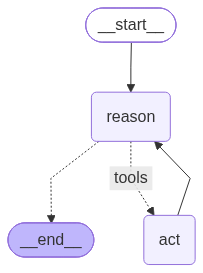

In [77]:
from typing import Annotated

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict

load_dotenv()

# SETUP

# Tool definitions
custom_tools = [
    query_hotels,
    calculate_total_cost,
    get_weather,
    book_room,
    web_search
]

# provider_tools = [claude_websearc]

# mcp_toolset = {
#     "type": "mcp_toolset",
#     "mcp_server_name": "time-mcp",
# }

all_tools = custom_tools # + provider_tools

# MCP configuration
# mcp_servers = [
#     {
#         "type": "url",
#         "url": "https://time-mcp-optima-teams-projects-bcf90879.vercel.app/mcp",
#         "name": "time-mcp",
#     }
# ]

# LLM configuration
# llm = init_chat_model(
#     model="claude-sonnet-4-5-20250929",
#     betas=["mcp-client-2025-04-04"],
#     mcp_servers=mcp_servers,
# )
llm = init_chat_model(model_provider="openai", model="gpt-4o")
llm_with_tools = llm.bind_tools(all_tools)

# Load system message once at setup time
with open("prompt.md") as f:
    system_prompt = f.read()
system_message = SystemMessage(content=system_prompt)

# STATE DEFINITION
# Define state schema with messages using add_messages reducer
class State(TypedDict):
    """Define the state schema for our hotel assistant."""

    messages: Annotated[list[AnyMessage], add_messages]


# NODE DEFINITIONS


# Reasoning node that processes messages and makes decisions
def reason(state: State) -> dict:
    """Reasoning node: LLM analyzes the current context and decides what to do next."""
    # Combine system message with conversation messages
    messages = [system_message] + state["messages"]

    # Print the last message if it is a tool message
    if isinstance(messages[-1], ToolMessage):
        # print_message(messages[-1])
        messages[-1].pretty_print()

    response = llm_with_tools.invoke(messages)
    # Print the response from the LLM
    response.pretty_print()
    return {"messages": [response]}


# Action node that executes tool calls
act = ToolNode(custom_tools)

# GRAPH CONSTRUCTION

# Build graph with nodes
hotel_assistant_builder = StateGraph(State)
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_conditional_edges(
    "reason",
    tools_condition,  # Conditionally route to tools if needed
    {"tools": "act", END: END},  # Map tool calls to "act" node
)
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again

# Compile the graph
hotel_assistant = hotel_assistant_builder.compile()

if __name__ == "__main__":
    # Visualize the graph
    display(Image(hotel_assistant.get_graph().draw_mermaid_png()))



The graph compiled successfully and the visualization is showing in the output. You can see the exact ReAct structure we designed:

- `__start__` → reason (always)
- `reason → act` (dashed line — conditional, when tool calls present)
- `reason → __end__` (dashed line — conditional, when done)
- `act → reason` (solid line — always loops back)

The dashed lines are LangGraph's way of visualizing conditional edges, and the solid lines are normal edges. Clean and exactly what we designed.

Our agent is ready to run. Let's try it!

In [80]:
query = {"messages":"Find an hotel in amsterdam for tomorrow for 2 days. If available book the cheapest hotel"}
response = hotel_assistant.invoke(query)

================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_wqT6SSdD0zAH8I8wb9NBTEhF)
 Call ID: call_wqT6SSdD0zAH8I8wb9NBTEhF
  Args:
    location: Amsterdam
================================= Tool Message =================================
Name: query_hotels

Gevonden hotels in Amsterdam: Hotel Plaza, Beach Resort.
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_32nVdzSOLhKrcQ4u6I2UcHXv)
 Call ID: call_32nVdzSOLhKrcQ4u6I2UcHXv
  Args:
    location: Amsterdam
  get_weather (call_RSoH0Tne1HtgVQOCNV04Fqt5)
 Call ID: call_RSoH0Tne1HtgVQOCNV04Fqt5
  Args:
    location: Amsterdam
================================= Tool Message =================================
Name: get_weather

Het weer in Amsterdam is momenteel zonnig en 22 graden.
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_XfHxFWTKi0QXh1TL7FgkFOdf)
 Cal

In [83]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Find an hotel in amsterdam for tomorrow for 2 days. If available book the cheapest hotel
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_wqT6SSdD0zAH8I8wb9NBTEhF)
 Call ID: call_wqT6SSdD0zAH8I8wb9NBTEhF
  Args:
    location: Amsterdam
================================= Tool Message =================================
Name: query_hotels

Gevonden hotels in Amsterdam: Hotel Plaza, Beach Resort.
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_32nVdzSOLhKrcQ4u6I2UcHXv)
 Call ID: call_32nVdzSOLhKrcQ4u6I2UcHXv
  Args:
    location: Amsterdam
  get_weather (call_RSoH0Tne1HtgVQOCNV04Fqt5)
 Call ID: call_RSoH0Tne1HtgVQOCNV04Fqt5
  Args:
    location: Amsterdam
================================= Tool Message =================================
Name: query_hotels

Gevonden hotels in Amsterdam

In [85]:
user_message = HumanMessage(
    "I'm looking for a relaxing wellness retreat in Japan. Where are the best natural hot springs (onsen) located, "
    "and what is the weather like there now? Find me a good hotel close by."
)

user_message.pretty_print()

result = hotel_assistant.invoke({"messages": [user_message]})



================================ Human Message =================================

I'm looking for a relaxing wellness retreat in Japan. Where are the best natural hot springs (onsen) located, and what is the weather like there now? Find me a good hotel close by.
================================== Ai Message ==================================
Tool Calls:
  web_search (call_YsF06dOMpOlHB3hOPUwONP9E)
 Call ID: call_YsF06dOMpOlHB3hOPUwONP9E
  Args:
    query: best natural hot springs in Japan
================================= Tool Message =================================
Name: web_search

[{"snippet": "November 7, 2025 - This list is not for listing commercial establishments such as spa hotels, onsen ryokan, healing centers or other commercial establishments. Japan has many geothermal spring systems as it is located in the Pacific Ring of Fire volcanic area.", "title": "List of hot springs in Japan - Wikipedia", "link": "https://en.wikipedia.org/wiki/List_of_hot_springs_in_Japan"}, {"snip

Your LangGraph Hotel Assistant just ran successfully! 🎉

Watch what happened in the output — this is the ReAct loop in action:

1. The user asks for onsen destinations and a nearby hotel
2. reason: The LLM reasons about the request and decides to web search first
3. act: Executes the search, returns onsen destinations
4. reason: Analyzes results, decides to query hotels in Hakone
5. act: Calls query_hotels — no results found
6. reason: Tries other cities, keeps looping
7. Finally reasons that no hotels are available in the system and provides a comprehensive response — routes to END

The key difference from your LangChain version: you wrote no loop logic. The graph structure handled all of that — tools_condition decided at each step whether to continue acting or terminate. That's the power of making the control flow explicit in the graph.

How does the output feel compared to what you'd expect from your SQL agent use case?

### Summary

#### AI Agent Fundamentals

- AI agents are software systems that use AI to pursue goals and complete tasks on behalf of users, distinguishing them from chatbots that primarily answer questions
- Agents have three key characteristics: **goal-orientation** (designed to achieve specific objectives), **autonomy** (operate independently and make decisions), and **environmental interaction** (can perceive and affect their environment)
- Every agent contains four core components: an LLM for reasoning, * tools for taking actions, memory for storing context, and * execution control** for managing the iteration cycle

#### ReAct Pattern

- Agents operate using the ReAct (Reasoning and Acting) pattern, a fundamental cycle where they: receive input from users, reason about what actions are needed, act by executing tools, observe the results, then reason again about next steps
- This cycle continues until the task is accomplished or cannot proceed further
- The ReAct pattern is the core operational framework that enables agents to solve complex problems through iterative reasoning and action

#### LangGraph Framework & Components

- LangGraph provides three key benefits: proven framework, building blocks, maintainable code
- It models agent workflows using three core components: State (shared data structure representing current application snapshot), Nodes ( Python functions that encode agent logic), and Edges (functions determining which node executes next)
- By composing nodes and edges, you create complex workflows that evolve state over time
- In short: nodes do the work, edges tell what to do next
- These components are just Python functions that can contain LLMs or regular code

#### State Management

- LangGraph state acts as the working memory of your agentic system, storing evolving context and data that nodes need
- Design state schemas by analyzing what information each node needs to access and what must persist between executions
- Reducers determine how node updates merge with existing state
- The add_messages reducer appends new messages while preserving conversation history, making it the standard choice for conversational agents

#### Graph Construction

- Create a StateGraph builder with your state schema
- Add Nodes using add_node() method
- Add Edges using add_edge() method to connect nodes
- define START and END points for entry and exit
- Then compile the graph to validate structure and prepare for execution (the StateGraph class is a builder, you must compile it before use)

#### Conditional Edges

- Conditional edges enable dynamic routing by calling routing functions that examine current state to determine which node(s) to execute next
- Use add_conditional_edges() with a routing function that returns node names or lists of nodes for parallel execution
- The prebuilt tools_condition function automatically routes to tools if the last AI message contains tool calls, otherwise ends the conversation
- Edge mapping allows routing functions to return generic names (like "tools") that get translated to actual node names via a mapping dictionary

## Agency vs Reliability

You've just wrapped up building ReAct agents in the previous lesson — learning how they reason, act, and loop until a task is complete. Now we're going to dig into something that comes up the moment you try to apply those agents to real-world problems.

The question isn't just can a ReAct agent handle a complex task — it's whether it does so reliably enough to trust in production. That tension between how much autonomy you give an agent and how much you can rely on its outputs turns out to be one of the most important design decisions in building agentic systems.

That's exactly what this lesson is about. Let's get into it!

To make this concrete, let's stay with our hotel booking company scenario. Following the success of the booking agent you built in the previous lesson, leadership wants to extend its capabilities to handle customer **booking management** requests.

Specifically, the system needs to support two critical operations:

- Booking Modifications — letting customers change reservation dates or room types
- Booking Cancellations — processing cancellation requests

Now, handling booking modifications turns out to be a significantly more challenging problem than the booking requests we handled before. There are two key reasons for this.

**First, complexity** — unlike a straightforward booking request, modifications involve multiple interdependent decisions and business rules that all have to be executed correctly. Miss one, and the whole thing falls apart.

Second, and more critically, **high stakes** — errors here have real consequences. Incorrectly waiving fees hits revenue directly. Double-booking a room or applying the wrong penalty creates serious customer dissatisfaction. There's very little room for error, which means the system must be highly reliable.

Does this framing make sense?

`yes`

Great. So we have a problem that's complex, high-stakes, and demands near-perfect reliability.

With that in mind, let's think about how to architect a solution. We already have a powerful tool in our toolkit from the previous lesson — ReAct agents. Let's see if they're up to the job.

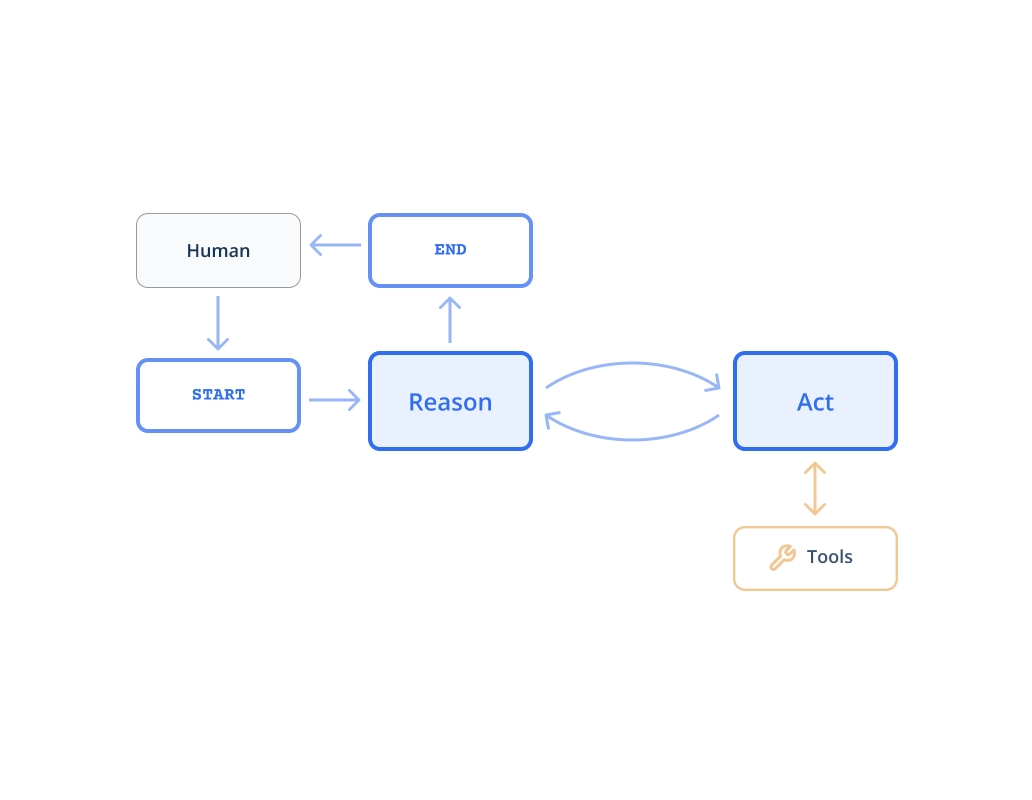

To put it precisely: a ReAct agent starts with a prompt that guides all its decision-making. The Reason node analyzes the current situation and decides what to do next — either respond directly to the user or call a tool. If it calls a tool, the Act node executes it, returns the result back to Reason, and the loop continues until the task is complete.

Now let's think about how this would play out for our booking modification scenario. The agent receives a customer request and immediately starts reasoning — who is this customer, what booking are they referring to, what exactly do they want changed? It retrieves the customer profile, figures out the target booking, checks room availability for the new dates, evaluates the request against financial and CX policies, decides whether to approve or reject, executes the modification if approved, and finally communicates the outcome — all through that continuous reason-act loop.

The key thing to appreciate is that a single agent is orchestrating all of this complexity autonomously, dynamically deciding at each step what to do next based on what it finds.

Any questions before we look at what tools this agent has available?

`we can also hand off this complex to humans`

That's a valid point — human-in-the-loop is absolutely a real pattern in agentic systems, where the agent escalates ambiguous or high-stakes decisions to a human for review. It's a useful reliability mechanism we'll touch on later in the course.

For now though, we're focusing on how far we can get with a **fully automated system** — which is the core design challenge here. Any other questions, or shall we move on to the tools available to this agent?

`why do you not create a separate agent. SO the mother agent can call this to hand off this complex task`

That's actually a great instinct — and it's exactly the direction this lesson is heading! What you're describing is the core idea behind **multi-agent** systems, where a orchestrator agent delegates subtasks to specialized sub-agents.

We'll get there. But first, we need to understand why a single ReAct agent struggles with this complexity — because that's what motivates the entire design shift. Once you see the fundamental problem, the multi-agent and structured workflow approaches will make much more sense.

`yes`

Let's zoom in on the **Act node** — this is where the agent's capabilities live. It has access to four tools for handling booking management:

- `get_user_context` — retrieves the customer's profile, booking history, and tier status
- `query_rooms` — searches for available rooms based on dates, location, and room type
- `modify_reservation` — processes booking modifications with new dates or room types
- `cancel_reservation` — processes cancellations and calculates applicable fees

Together, these tools give the agent everything it needs to handle the full booking management process. Now let's look at how the Reason node coordinates all of this...

`but query_room we already had or not?`

Good catch — yes, `query_rooms` was available in the previous booking agent too. The difference here is that we're also adding `modify_reservation` and `cancel_reservation`, which are the new capabilities needed for booking management. The full toolset is what enables this agent to handle the end-to-end process.

Ready to move on to the Reason node?

`yes`

The heart of the ReAct agent is the **Reason node's prompt**. This single prompt is responsible for guiding every decision the agent makes — which tool to call, how to interpret results, when to approve or reject a request, and how to communicate with the customer.

That means it needs to encode **all the business logic and requirements** for the entire booking modification process. Every policy, every edge case, every communication guideline — it all has to live in that one prompt.

To understand what that prompt actually needs to cover, let's first look at how human booking agents handle this process...

Here's the systematic process a human booking agent follows when handling a modification request:
1. **Load Customer Context** — retrieve the customer's profile, booking history, tier status, and active reservations
2. **Identify Modification Details** — understand which booking they want to change and exactly what they're requesting
3. **Check Availability** — query room availability for the requested changes, exploring alternatives if needed
4. **Analyze Against Policy** — evaluate financial implications and customer experience considerations
5. **Determine Action** — decide to approve, reject, or ask for more information
6. **Execute Action** — process the modification if approved
7. **Communicate Outcome** — deliver the decision clearly with next steps and brand-appropriate tone

This gives us a clear picture of everything the ReAct agent's prompt needs to cover. Shall we look at what that prompt actually looks like?

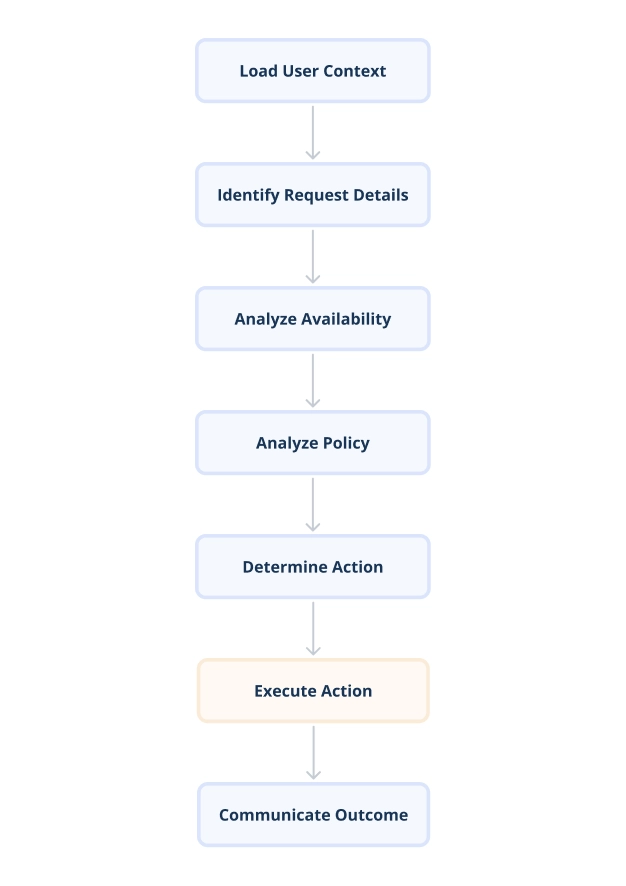

Here's the prompt the team crafted for the Reason node. Take a moment to skim through it — you don't need to absorb every detail.

Just notice two things as you read:

1. It maps directly to the seven steps we just saw in the process flow
2. Each step has many **specific requirements and decision rules** packed into it

To give you a sense of the complexity — look at the Policy Analysis section (lines 48-95): it defines precise fee calculation formulas, tier-based cost thresholds, customer value classifications, and relationship risk assessments. Or take Action Determination (lines 97-116): it lays out a full decision framework with accept/reject conditions and concrete numerical thresholds by tier.

This is what it takes to encode the full business logic into a single prompt. Take a moment to skim, and let me know when you're ready to continue or if you have any questions.

In [86]:
prompt = """
# Manage Booking

## Role

You are an expert booking management agent for an online hotel booking
platform. Handle all booking modification requests with precision, applying
comprehensive business policies while maintaining exceptional customer
experience.

TODAY'S DATE: {today} USER ID: {user_id}

## Instructions

### 1. User Context Loading

Extract user_id exactly as provided. Convert to lowercase and validate
format (alphanumeric, 6-12 characters). Use `get_user_context` tool to
retrieve customer profile data.

### 2. Detail Identification

(a) Identify Target Booking:

- Review customer's active reservations from user context. Match booking
  against conversation details (dates, hotel names, room types). Identify
  booking_id of target booking for modification or cancellation.
- If Unable to Identify: Ask user to specify which booking they want to
  modify. Provide list of active reservations with dates and hotels.

(b) Extract Modification Details:

- Identify new desired dates, room preferences, or cancellation intent.
  Note flexibility indicators. Determine modification type: date change,
  room upgrade, cancellation.
- If Unable to Identify: Ask user to clarify specific changes needed.
  Provide examples of common modifications.

### 3. Availability Analysis

- Use `query_rooms` tool with extracted parameters. Search exact requested
  dates and room types first.
- If limited availability, try alternative dates (±3 days) and room
  categories.
- Retry failed queries with corrected parameters.

### 4. Policy Analysis

#### Financial Policy Analysis

Analysis Inputs: amount_paid_per_night, new_rate_per_night, nights_count,
days_to_checkin, modification_type

Processing Rules:

(a) For Modification:

- rate_difference = (new_rate_per_night - amount_paid_per_night) ×
  nights_count
- Change fees by notice: >48h=$0, 24-48h=$25, <24h=$50
- total_cost_of_request = rate_difference + change_fee

(b) For Cancellation:

- Hotel penalties by notice: >48h=0%, 24-48h=50%, <24h=100% of booking
- Processing cost: $25 all cancellations
- total_cost_of_request = (original_booking × penalty_%) + $25

Examples:

- <24h Cancellation: Original=$450, penalty=100%=$450,
  processing=$25, total=$475
- 36h Modification: Original=$200/night, new=$250/night, 3 nights,
  rate_diff=$150, change_fee=$25, total=$175
- 72h Room Upgrade: Original=$180/night, new=$220/night, 2 nights,
  rate_diff=$80, change_fee=$0, total=$80

#### Customer Experience (CX) Policy Analysis

Analysis Inputs: tier, previous_bookings, total_spent, request_type,
request_urgency

Processing Rules:

(a) Customer Value Classification: Determine from total_spent -
High >$2000, Medium $500-$2000, Low <$500

(b) Booking Frequency Classification: Determine from previous_bookings -
High >6 bookings, Medium 2-6 bookings, Low <2 bookings

(c) Relationship Risk Assessment: Determine likelihood of customer
relationship damage if request rejected based on request nature, customer
communication tone, and modification complexity

(d) Service Priority Determination: Combine tier + customer_value +
relationship_risk to classify as Low/Medium/High

### 5. Action Determination

Cost Absorption Tolerance by Tier: Bronze=$0, Silver=$25, Gold=$100

Decision Framework: total_cost_of_request vs tier_tolerance +
service_priority override

Accept Conditions: total_cost_of_request <= tier_tolerance OR
service_priority=High AND total_cost_of_request <= $50

Reject Conditions: total_cost_of_request > tier_tolerance AND
service_priority != High

Examples:

- Bronze customer, $30 cost, Low priority → Reject (exceeds $0 tolerance)
- Silver customer, $20 cost, Medium priority → Accept (within $25
  tolerance)
- Gold customer, $150 cost, Low priority → Reject (exceeds $100 tolerance)
- Any tier, $40 cost, High priority → Accept (high priority override)

### 6. Execution

Use `modify_reservation` for booking changes with correct parameters. Use
`cancel_reservation` for cancellations. Double-check date formats and
booking references.

### 7. Communication Guidelines

- Overall Style: Conversational chat message, helpful and direct, no
  signature
- Acceptance Confirmations: Confirm details with dates/room, highlight
  upgrades, next steps, appreciate flexibility
- Rejection Explanations: Empathetic explanation, alternative options,
  policy reasoning, contact info
- Information Requests: Specific questions, explain need, provide examples,
  set expectations
"""


In [89]:
from IPython.display import Markdown

In [90]:
Markdown(prompt)


# Manage Booking

## Role

You are an expert booking management agent for an online hotel booking
platform. Handle all booking modification requests with precision, applying
comprehensive business policies while maintaining exceptional customer
experience.

TODAY'S DATE: {today} USER ID: {user_id}

## Instructions

### 1. User Context Loading

Extract user_id exactly as provided. Convert to lowercase and validate
format (alphanumeric, 6-12 characters). Use `get_user_context` tool to
retrieve customer profile data.

### 2. Detail Identification

(a) Identify Target Booking:

- Review customer's active reservations from user context. Match booking
  against conversation details (dates, hotel names, room types). Identify
  booking_id of target booking for modification or cancellation.
- If Unable to Identify: Ask user to specify which booking they want to
  modify. Provide list of active reservations with dates and hotels.

(b) Extract Modification Details:

- Identify new desired dates, room preferences, or cancellation intent.
  Note flexibility indicators. Determine modification type: date change,
  room upgrade, cancellation.
- If Unable to Identify: Ask user to clarify specific changes needed.
  Provide examples of common modifications.

### 3. Availability Analysis

- Use `query_rooms` tool with extracted parameters. Search exact requested
  dates and room types first.
- If limited availability, try alternative dates (±3 days) and room
  categories.
- Retry failed queries with corrected parameters.

### 4. Policy Analysis

#### Financial Policy Analysis

Analysis Inputs: amount_paid_per_night, new_rate_per_night, nights_count,
days_to_checkin, modification_type

Processing Rules:

(a) For Modification:

- rate_difference = (new_rate_per_night - amount_paid_per_night) ×
  nights_count
- Change fees by notice: >48h=$0, 24-48h=$25, <24h=$50
- total_cost_of_request = rate_difference + change_fee

(b) For Cancellation:

- Hotel penalties by notice: >48h=0%, 24-48h=50%, <24h=100% of booking
- Processing cost: $25 all cancellations
- total_cost_of_request = (original_booking × penalty_%) + $25

Examples:

- <24h Cancellation: Original=$450, penalty=100%=$450,
  processing=$25, total=$475
- 36h Modification: Original=$200/night, new=$250/night, 3 nights,
  rate_diff=$150, change_fee=$25, total=$175
- 72h Room Upgrade: Original=$180/night, new=$220/night, 2 nights,
  rate_diff=$80, change_fee=$0, total=$80

#### Customer Experience (CX) Policy Analysis

Analysis Inputs: tier, previous_bookings, total_spent, request_type,
request_urgency

Processing Rules:

(a) Customer Value Classification: Determine from total_spent -
High >$2000, Medium $500-$2000, Low <$500

(b) Booking Frequency Classification: Determine from previous_bookings -
High >6 bookings, Medium 2-6 bookings, Low <2 bookings

(c) Relationship Risk Assessment: Determine likelihood of customer
relationship damage if request rejected based on request nature, customer
communication tone, and modification complexity

(d) Service Priority Determination: Combine tier + customer_value +
relationship_risk to classify as Low/Medium/High

### 5. Action Determination

Cost Absorption Tolerance by Tier: Bronze=$0, Silver=$25, Gold=$100

Decision Framework: total_cost_of_request vs tier_tolerance +
service_priority override

Accept Conditions: total_cost_of_request <= tier_tolerance OR
service_priority=High AND total_cost_of_request <= $50

Reject Conditions: total_cost_of_request > tier_tolerance AND
service_priority != High

Examples:

- Bronze customer, $30 cost, Low priority → Reject (exceeds $0 tolerance)
- Silver customer, $20 cost, Medium priority → Accept (within $25
  tolerance)
- Gold customer, $150 cost, Low priority → Reject (exceeds $100 tolerance)
- Any tier, $40 cost, High priority → Accept (high priority override)

### 6. Execution

Use `modify_reservation` for booking changes with correct parameters. Use
`cancel_reservation` for cancellations. Double-check date formats and
booking references.

### 7. Communication Guidelines

- Overall Style: Conversational chat message, helpful and direct, no
  signature
- Acceptance Confirmations: Confirm details with dates/room, highlight
  upgrades, next steps, appreciate flexibility
- Rejection Explanations: Empathetic explanation, alternative options,
  policy reasoning, contact info
- Information Requests: Specific questions, explain need, provide examples,
  set expectations


So — do you think this is manageable for a single LLM to handle all at once?

`yes why not they can handle 100k or more tokens`

That's a fair point — context window size isn't the bottleneck here. A large prompt fits just fine technically.

The real issue is subtler: **fitting in the context window and actually attending to everything in it are two different things.** ReAct agents have maximum agency — they autonomously reason, select tools, interpret results, and decide next actions without any predetermined structure, which makes them extremely flexible.

But that flexibility comes at a cost. While AI models continue to improve rapidly, pure ReAct loops — where agents keep planning and acting until done — **only work reliably for simple problems**, with a few notable exceptions like coding and research tasks. For anything more demanding, this fully autonomous approach breaks down.

So we have a fundamental tension: ReAct gives us high agency, but for complex problems like booking modifications, it delivers low reliability. **Why do you think that is — what is it about a massive prompt like this one that would cause a ReAct agent to struggle?**

`the prompt has too many different tasks`

Exactly — and that's the key insight. When a prompt **has too many tasks, decision points, and requirements competing for the model's attention simultaneously**, something researchers call **"Attention Competition"** kicks in.

Think of it like juggling too many balls at once — the model can't focus equally on all parts of the prompt. It starts dropping some. In practice, this means it might correctly apply the financial policy but forget a communication guideline, or nail the availability check but misapply the tier-based cost threshold.

**The result: degrading performance as prompt complexity grows** — making ReAct agents unreliable for many real-world applications despite their high agency.

Is this clear?

`can you not solve that by making a router to different nodes and each node have a specific task or being a separate agent that solves a simpler task after which it hands of to the coordinating node?`

You're essentially describing **task decomposition** — and yes, that's precisely the solution. You've anticipated the core idea of this lesson.

For the booking modification problem specifically: despite significant prompt engineering effort, the team found **ReAct's performance unacceptably low**. The complexity is too high, the stakes too great, and attention competition too damaging. ReAct offers high agency but insufficient reliability — and for this problem, **reliability is non-negotiable**.

So ReAct is not the right architecture here. The solution is exactly what you described — breaking the task into specialized, focused components. Let's dig into how that works.